In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import stark as sk

/Users/ckw/opt/anaconda3/envs/metacell2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import scanpy as sc
import metacells as mc
import numpy as np
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import os
import h5py

lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])
pca_vec = np.load('/Users/ckw/warehouse/metacell/stark/test_output/pca_vec_500000.npy')
umap_vec = np.load('/Users/ckw/warehouse/metacell/stark/test_output/umap_vec_500000.npy')
cell_embeddings = pca_vec  # 或者 umap_vec，取决于你想用哪个作为输入
print(pca_vec.shape, umap_vec.shape, len(lb))
adata = ad.AnnData(cell_embeddings)
adata.obs['cell_type'] = lb
adata.obsm['X_pca'] = pca_vec
adata.obsm['X_umap'] = umap_vec


# 用PCA建KNN图
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15)

# 之后可以用图分区（leiden/louvain作为对比基线）
sc.tl.leiden(adata, resolution=0.1)
# mc.pl.compute_direct_metacells(adata, random_seed=123456)
# 关键步骤：把PCA坐标转成MC2能接受的格式
# 1. 平移到非负
pca_shifted = pca_vec - pca_vec.min()
# 2. 缩放到合理的UMI量级（模拟UMI counts）
pca_scaled = (pca_shifted / pca_shifted.max() * 1000).astype(np.float32)

# 构造AnnData，X用处理后的PCA
adata = ad.AnnData(X=pca_scaled)
adata.obs['cell_type'] = lb



# 给每个PC维度一个名字（当作"基因"）
import pandas as pd
adata.var_names = [f"PC{i}" for i in range(pca_scaled.shape[1])]
adata.obs_names = [f"cell{i}" for i in range(pca_scaled.shape[0])]

mc.ut.set_name(adata, "hic_data")

mc.pl.mark_lateral_genes(adata)  # 不传任何基因，仅初始化
n_cells = adata.n_obs
target_n_metacells = 20  # 你想要的metacell数

# 反推target_metacell_umis
total_umi = adata.X.sum()
target_umis = int(total_umi / target_n_metacells)
print(f"Total UMI: {total_umi}, Target UMIs per metacell: {target_umis}")
# 关闭MC2内部的基因筛选（因为PC维度不是真正的基因）
mc.pl.compute_direct_metacells(
    adata,
    random_seed=123456,
    target_metacell_umis=target_umis,  # 关键：控制metacell数量
    select_min_gene_total=0,
    select_min_gene_top3=0,
    select_min_gene_relative_variance=0,
    select_min_genes=1,
    deviants_min_gene_fold_factor=8,
    deviants_max_cell_fraction=0.25,
    min_metacell_size=5,
)


mdata = mc.pl.collect_metacells(adata, random_seed=123456)
adata.obs.columns = ['label', 'dissolved', 'metacell', 'm_name']
adata.uns['X_pca'] = pca_vec    
adata.uns['X_umap'] = umap_vec
print(mdata)


(700, 114) (700, 2) 700


/var/folders/vj/gx99370d7_z4fq339y_07z700000gn/T/ipykernel_4721/2758850448.py:36: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.1)
set hic_data.var[lateral_gene]: 0 true (0%) out of 114 bools
set hic_data.layers[downsampled]: ndarray 700 X 114 float32s
set hic_data.uns[downsample_samples]: 24927
set hic_data.var[high_top3_gene]: 114 true (100%) out of 114 bools
set hic_data.var[high_total_gene]: 114 true (100%) out of 114 bools
/Users/ckw/opt/anaconda3/envs/metacell2/lib/python3.11/site-packages/metacells/utilities/computation.py:1563: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  result = np.reciprocal(mean_per_element, where=~zeros_mask)
set hic_data.var[high_relative_variance_gene

Total UMI: 17622968.0, Target UMIs per metacell: 881148


set metacells.obs[grouped]: [ 47, 39, 44, 43, 47, 46, 50, 38, 56, 53, 45, 24, 42, 40, 54, 24 ]
set metacells.obs[total_umis]: [ 1177685, 984183, 1105198, 1083029, 1183181, 1156750, 1261645, 958794, 1415037, 1330294, 1134478, 603531, 1055115, 1009337, 1354926, 605595 ]
set metacells.layers[total_umis]: ndarray 16 X 114 float32s
set metacells.obs[__zeros_downsample_umis]: [ 24909, 25114, 24995, 25061, 25062, 25052, 25171, 25106, 25184, 25018, 25077, 24971, 24903, 25011, 24941, 24818 ]
set metacells.layers[zeros]: ndarray 16 X 114 int32s
set hic_data.obs[metacell_name]: 700 <U8s
set metacells.var[lateral_gene]: 0 true (0%) out of 114 bools
set metacells.var[high_top3_gene]: 114 true (100%) out of 114 bools
set metacells.var[high_total_gene]: 114 true (100%) out of 114 bools
set metacells.var[high_relative_variance_gene]: 58 true (50.88%) out of 114 bools
set metacells.var[selected_gene]: 58 true (50.88%) out of 114 bools
set metacells.uns[outliers]: 8
set metacells.uns[metacells_algorithm

AnnData object with n_obs × n_vars = 16 × 114
    obs: 'grouped', 'total_umis', '__zeros_downsample_umis'
    var: 'lateral_gene', 'high_top3_gene', 'high_total_gene', 'high_relative_variance_gene', 'selected_gene'
    uns: '__name__', 'outliers', 'metacells_algorithm'
    layers: 'total_umis', 'zeros'


In [3]:
adata.obsm

AxisArrays with keys: 

In [4]:
hdata = sk.create_hdata_from_adata(adata,
                                 data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
                                output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
                                genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
                                chrom_list=[f"chr{i}" for i in range(1, 23)],
                                resolution=[500000])
hdata

HData object with 700 cells and 0 metacells
    resolutions: [500000]
    obs: ['label', 'dissolved', 'metacell', 'm_name']
    views_pca: [500000]
    views_umap: [500000]
    views_embedding: []
    views_mat: []
    views_is: []
    uns keys: []

In [5]:
purity_df, metrics = sk.tl.evaluate(hdata, hdata.obs['label'])


正在计算评估指标...
✅ 指标计算完成！(发现 14 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.6454
模型准确率 (Accuracy)      : 0.6771
全局加权分 (Global Score)  : 0.5541
过度融合指标 (WCOS)       : 0.9457
Hub 权重不纯度 (HWIS)     : 0.9800
----------------------------------------
✅ 评估指标计算完成，纯度得分(EP_v2等)已同步至 hdata.metacells。


/Users/ckw/warehouse/metacell/stark/stark/tl/wrappers.py:191: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  celltype_fraction = df.groupby("Metacell").apply(celltype_frac)
/Users/ckw/warehouse/metacell/stark/stark/tl/wrappers.py:192: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  celltype_dom = df.groupby("Metacell").apply(dominant_celltype)


/Users/ckw/warehouse/metacell/stark/stark/pl/plot_m.py:203: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


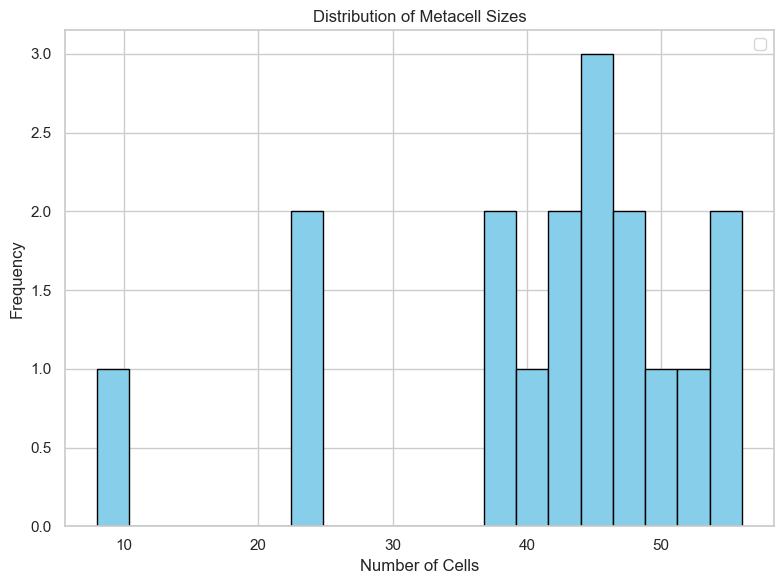

In [6]:
sk.pl.plot_metacell_sizes(hdata,)

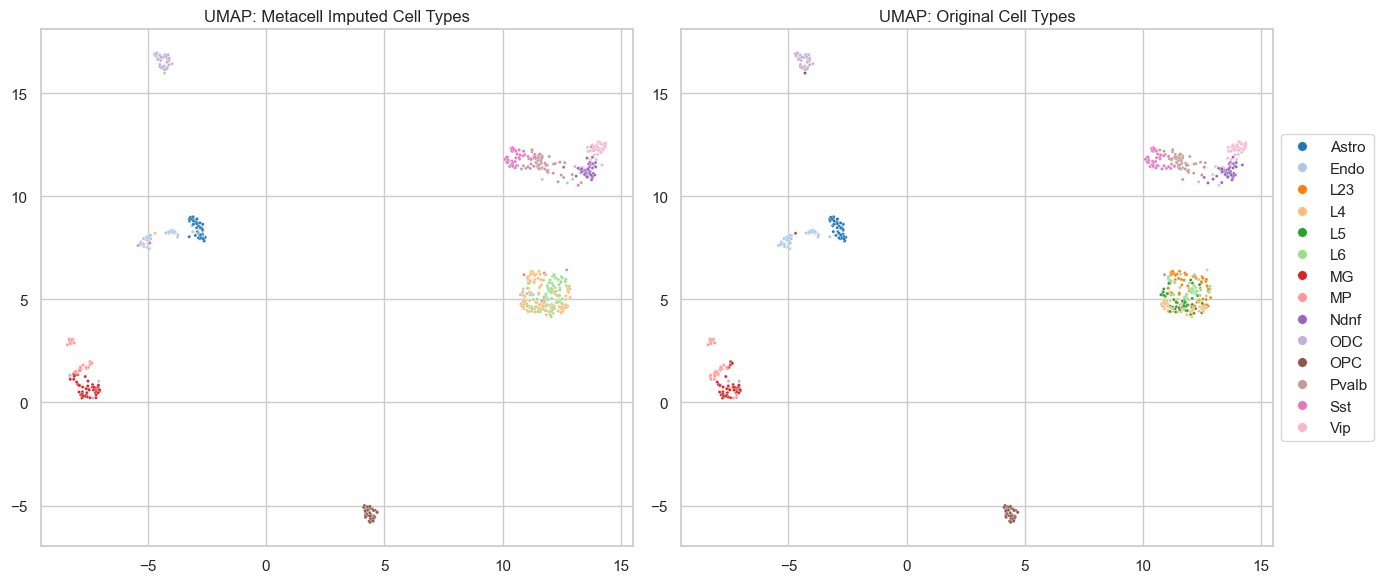

In [7]:
sk.pl.plot_umap_comparison(hdata, resolution=500000)


>>> 7-10. 绘图与评估...


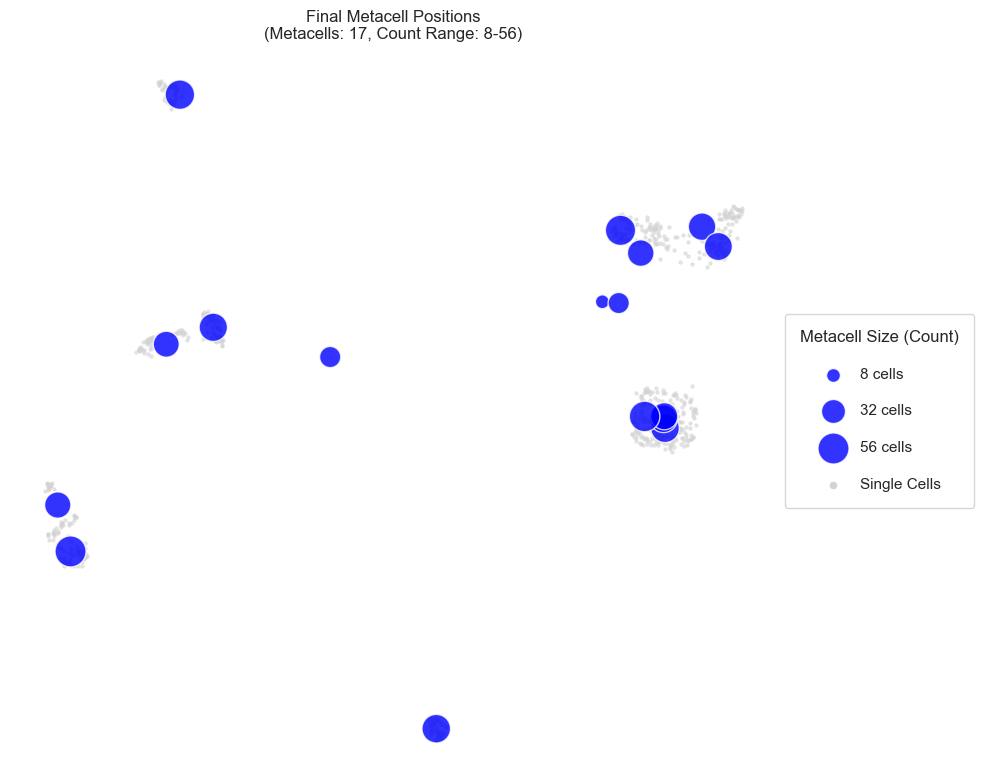

In [8]:


# ==========================================
# 7 - 10. 后续评估与可视化
# ==========================================
print("\n>>> 7-10. 绘图与评估...")
sk.pl.plot_metacells(hdata, resolution=500000, max_size=500, min_size=100)


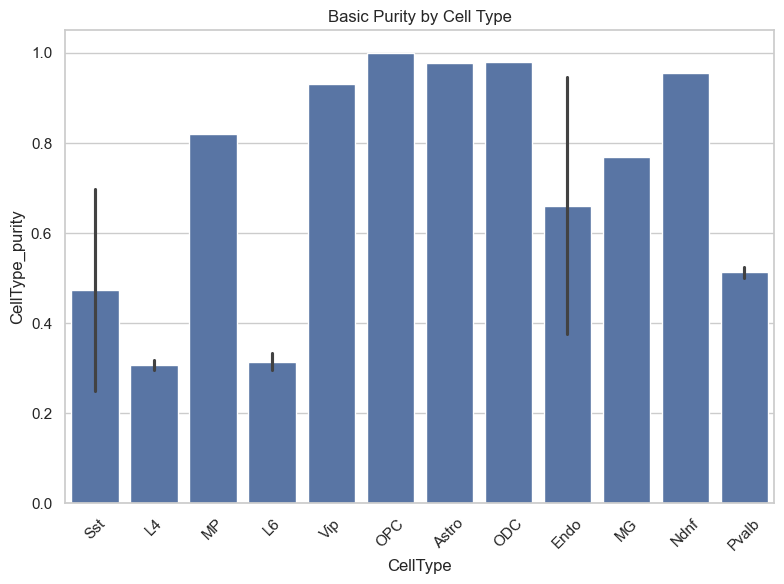

In [9]:
sk.pl.plot_basic_purity(hdata,)